***Codigo analisis de datos "Análisis de datos juegos de Nintendo switch con mayor número de ventas."***

1) Se importan las librerias que se van a usar en el codigo.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

2)Se importa la base de datos

In [9]:
#Se crean variables para poder usar la base de datos en el codigo.
data = "/content/Switchgames.csv"
df = pd.read_csv(data, sep=",")
df

,No.,Title,Copies sold,As of,Release date,Genre(s),Developer(s),Publisher(s)
0,1,Mario Kart 8 Deluxe,33.41,31-Dec-20,28-Apr-17,Kart racing,Nintendo EPD,Nintendo
1,2,Animal Crossing: New Horizons,31.18,31-Dec-20,20-Mar-20,Social simulation,Nintendo EPD,Nintendo
2,3,Super Smash Bros. Ultimate,22.85,31-Dec-20,7-Dec-18,Fighting,Bandai Namco Studios,Nintendo
3,4,The Legend of Zelda: Breath of the Wild,21.45,31-Dec-20,3-Mar-17,Action-adventure,Nintendo EPD,Nintendo
4,5,Pokémon Sword and Shield,20.35,31-Dec-20,15-Nov-19,Role-playing,Game Freak,The Pokémon Company
5,6,Super Mario Odyssey,20.23,31-Dec-20,27-Oct-17,Platformer,Nintendo EPD,Nintendo
6,7,Super Mario Party,13.82,31-Dec-20,5-Oct-18,Party,NDcube,Nintendo
7,8,"Pokémon: Let's Go, Pikachu! and Let's Go, Eevee!",13.00,31-Dec-20,16-Nov-18,Role-playing,Game Freak,The Pokémon Company
8,9,Splatoon 2,11.90,31-Dec-20,21-Jul-17,Third-person shooter,Nintendo EPD,Nintendo
9,10,New Super Mario Bros. U Deluxe,9.82,31-Dec-20,11-Jan-19,Platformer,Nintendo EPD,Nintendo


3)Se inicia el analisis de datos

a)**"Porcentaje de videojuegos de cada genero dentro de los videojuegos más vendidos."**

Tabla:

In [10]:
#Se crea una variable donde se llama a la columna 'Genre(s)' de la base de datos, se realiza un conteo de los elementos que conforman esta columna y se convierten estos datos a un diccionario.
gf = dict(df['Genre(s)'].value_counts())
#Posterior se crea una variable donde se transforma el diccionario a un objeto series pandas para mejor organizacion.
Serie=pd.Series(gf)
Serie

Platformer               7
Action-adventure         4
Role-playing             4
Fighting                 3
Party                    3
Action role-playing      3
Kart racing              2
Exergame                 2
Tactical role-playing    2
Hack and slash           1
Sports                   1
Social simulation        1
Tabletop game            1
Board game               1
Sandbox                  1
Real-time strategy       1
Third-person shooter     1
Action puzzle            1
Construction kit         1
Roguelike                1
Bullet hell              1
Rhythm                   1
dtype: int64

Grafica:

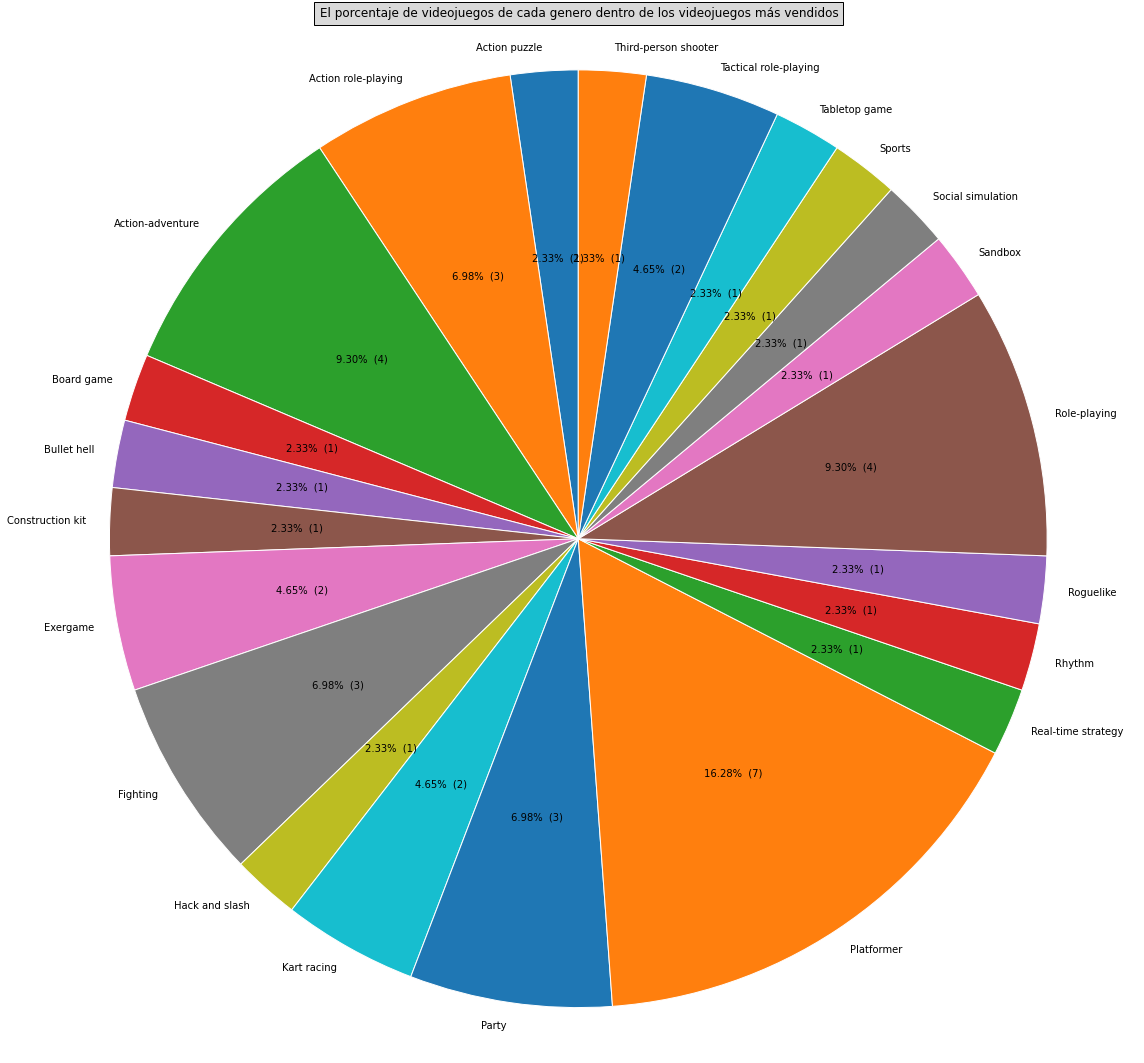

In [11]:
#Se crea una variable donde se llama a la columna 'Genre(s)' de la base de datos y se realiza un conteo de los elementos que conforman esta columna.
gf = df['Genre(s)'].value_counts()
#Se crean variables donde se usan las funciones de pandas .sort_index() y .index para una mejor organizacion de la grafica y poder mostrar los nombres de los elementos de 'Genre(s)' de forma correcta.
gf = gf.sort_index()
ind = gf.index
#Se utilizan los parametros de mathplot para hacer la grafica de pastel.
fig1, ax1 = plt.subplots(figsize=(20, 19))
#Se realiza una funcion para poder mostrar en la grafica los porcentajes y los valores.
def m(gf):
    def Funcion_valores(z):
        sum_total = sum(gf)
        valor = int(round(z*sum_total/100.0))
        return '{p:.2f}%  ({v:d})'.format(p=z,v=valor)
    return Funcion_valores
#Se ponen los parametros de la grafica
ax1.pie(gf, labels=ind,labeldistance=1.05, wedgeprops = { 'linewidth' : 1, 'edgecolor' : 'white' }, startangle=90, autopct= m(gf))
ax1.axis('equal') 
#Se el titulo de la grafica.
plt.title("El porcentaje de videojuegos de cada genero dentro de los videojuegos más vendidos", bbox={'facecolor':'0.85', 'pad':5})
plt.show()


**b)“Porcentaje de ventas por género de videojuegos”**

In [12]:
#Se crea una variable donde se llama a la columna 'Genre(s)' y 'Copies sold' de la base de datos, se agrupan los datos de 'Copies sold' con respecto a 'Genre(s)' y se realiza una sumatoria de los elementos de 'Copies sold' respecto a los elementos de 'Genre(s)' agrupados.
#Posterior se convierte a diccionario
Tabla_Copiasvendidas = dict(df[['Genre(s)', 'Copies sold']].groupby('Genre(s)').sum())
Tabla_Copiasvendidas


{'Copies sold': Genre(s)
 Action puzzle             1.44
 Action role-playing       4.48
 Action-adventure         36.04
 Board game                2.50
 Bullet hell               1.00
 Construction kit          1.31
 Exergame                  9.68
 Fighting                 26.39
 Hack and slash            3.50
 Kart racing              34.49
 Party                    20.20
 Platformer               52.70
 Real-time strategy        1.94
 Rhythm                    1.00
 Roguelike                 1.26
 Role-playing             38.40
 Sandbox                   2.24
 Social simulation        31.18
 Sports                    3.06
 Tabletop game             2.62
 Tactical role-playing     4.87
 Third-person shooter     11.90
 Name: Copies sold, dtype: float64}

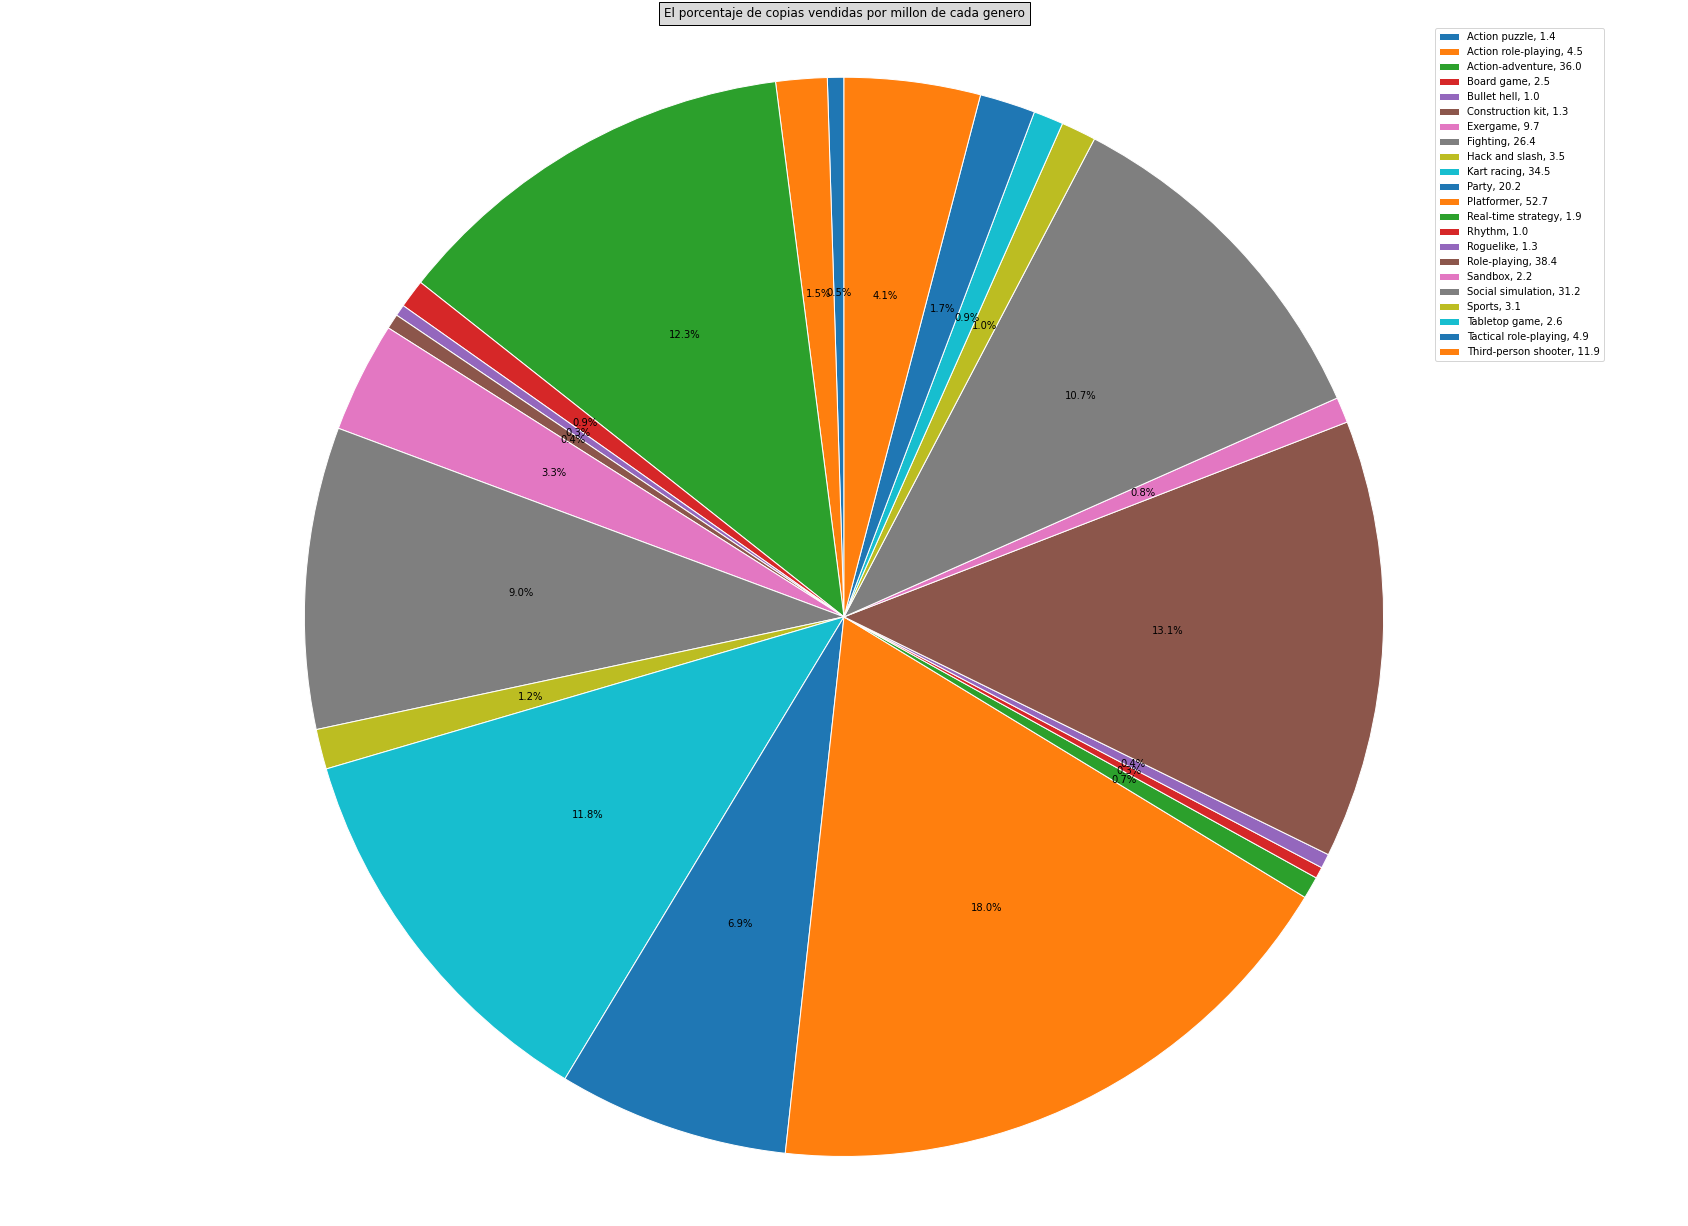

In [13]:
#Se crea una variable donde se llama a la columna 'Genre(s)' de la base de datos y se realiza un conteo de los elementos que conforman esta columna.
gf = df['Genre(s)'].value_counts()
#Se crean variables donde se usan las funciones de pandas .sort_index() y .index para una mejor organizacion de la grafica
# y poder mostrar los nombres de los elementos de 'Genre(s)' de forma correcta.
gf = gf.sort_index()
ind = gf.index
#Se crea una variable donde se llama a la columna 'Genre(s)' y 'Copies sold' de la base de datos. 
#Se agrupan los datos de 'Copies sold' con respecto a 'Genre(s)'. 
#Se realiza una sumatoria de los elementos de 'Copies sold' respecto a los elementos de 'Genre(s)' agrupados.
df_c = df[['Genre(s)', 'Copies sold']].groupby('Genre(s)').sum()
#Se llaman los datos de la variable anteriormente creada y se separan en una variable diferente.
x = df_c['Copies sold']
#Se utilizan los parametros de mathplot para hacer la grafica de pastel.
fig1, ax1 = plt.subplots(figsize=(30, 22))
#Se realiza una variable donde se crea un ciclo donde se utiliza una funcion zip(esta es un iteracion de tuplas),
# para poder mostran en la leyenda al lado de la grafica los valores de ventas por millon.
labels = [f'{l}, {s:0.1f}' for l, s in zip(ind, x)]
#Se ponen los parametros de la grafica.
ax1.pie(x, wedgeprops = { 'linewidth' : 1, 'edgecolor' : 'white' }, startangle=90,autopct= '%1.1f%%')
ax1.axis('equal')
#Se ponen los label y la legenda al lado de la grafica.
plt.title("El porcentaje de copias vendidas por millon de cada genero", bbox={'facecolor':'0.85', 'pad':5})
plt.legend(bbox_to_anchor=(0.85, 1), loc='best', labels=labels)
plt.show()

**"La media del número de copias vendidas por millón totales entre todos los géneros de videojuegos."**

In [14]:
MEDIA_genr = x.mean()
MEDIA_genr

13.281818181818181

**c)"Número de videojuegos desarrollados por cada compañía que hacen parte de la lista de los juegos  más vendidos"**

Tabla:

In [15]:
#Se crea una variable donde se llama a la columna 'Developer(s)' de la base de datos.
#Se realiza un conteo de los elementos que conforman esta columna y se convierten estos datos a un diccionario.
Num_P = dict(df['Developer(s)'].value_counts())
#Posterior se crea una variable donde se transforma el diccionario a un objeto series pandas para mejor organizacion.
Serie=pd.Series(Num_P)
Serie

Nintendo EPD                 13
Bandai Namco Studios          3
Game Freak                    2
NDcube                        2
Intelligent Systems           2
Monolith Soft                 2
Ubisoft Paris                 1
Dodge Roll                    1
Velan Studios                 1
Team Ninja                    1
PlatinumGames                 1
Spike Chunsoft                1
Good-Feel                     1
Square Enix                   1
Retro Studios                 1
Mojang                        1
Konami                        1
HAL Laboratory                1
Camelot Software Planning     1
Innersloth                    1
Omega Force                   1
Grezzo                        1
Nintendo                      1
Next Level Games              1
Imagineer                     1
dtype: int64

Grafica:

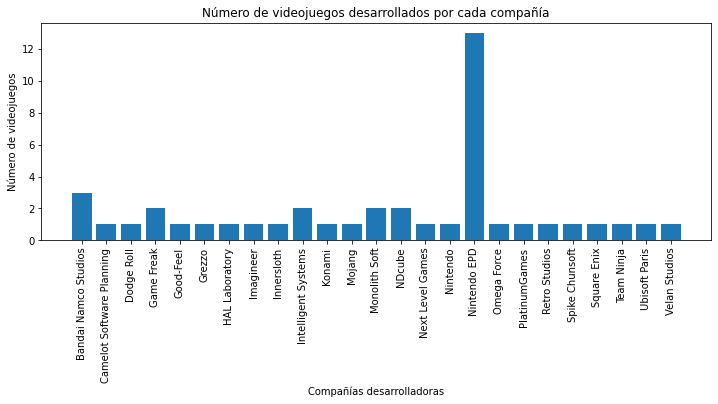

In [16]:
#Se crea una variable donde se llama a la columna 'Developer(s)' de la base de datos.
#Se realiza un conteo de los elementos que conforman esta columna.
Desa_num = df['Developer(s)'].value_counts()
#Se crean variables donde se usan las funciones de pandas .sort_index() y .index para una mejor organizacion de la grafica
# y poder mostrar los nombres de los elementos de 'Developer(s)' de forma correcta.
Desa_num = Desa_num.sort_index()
ind = Desa_num.index
#Se utilizan los parametros de mathplot para hacer la grafica de barras.
width = 0.35 
fig, ax = plt.subplots(figsize=(12,4))
#Se ponen los parametro de la grafica en sus ejes x y y.
ax.bar(ind,Desa_num)
plt.xticks(ind,rotation='vertical')
#Se ponen los label.
ax.set_xlabel('Compañías desarrolladoras')
ax.set_ylabel('Número de videojuegos')
ax.set_title('Número de videojuegos desarrollados por cada compañía')
plt.show()

**d)“Número de ventas de las empresas desarrolladoras en comparación con la media del número de ventas total”**

Tabla:

In [17]:
#Se crea una variable donde se llama a la columna 'Developer(s)' y 'Copies sold' de la base de datos, se agrupan los datos de 'Copies sold' con respecto a 'Developer(s)' y se realiza una sumatoria de los elementos de 'Copies sold' respecto a los elementos de 'Developer(s)' agrupados.
#Posterior se convierte a diccionario
dfcg_c = dict(df[['Developer(s)', 'Copies sold']].groupby('Developer(s)').sum())
dfcg_c

{'Copies sold': Developer(s)
 Bandai Namco Studios          25.01
 Camelot Software Planning      3.06
 Dodge Roll                     1.00
 Game Freak                    33.35
 Good-Feel                      1.84
 Grezzo                         4.38
 HAL Laboratory                 2.93
 Imagineer                      1.00
 Innersloth                     3.20
 Intelligent Systems            5.92
 Konami                         2.50
 Mojang                         2.24
 Monolith Soft                  3.40
 NDcube                        16.44
 Next Level Games               9.13
 Nintendo                       8.32
 Nintendo EPD                 153.83
 Omega Force                    3.50
 PlatinumGames                  1.08
 Retro Studios                  2.65
 Spike Chunsoft                 1.26
 Square Enix                    2.00
 Team Ninja                     1.08
 Ubisoft Paris                  2.00
 Velan Studios                  1.08
 Name: Copies sold, dtype: float64}

Grafica:

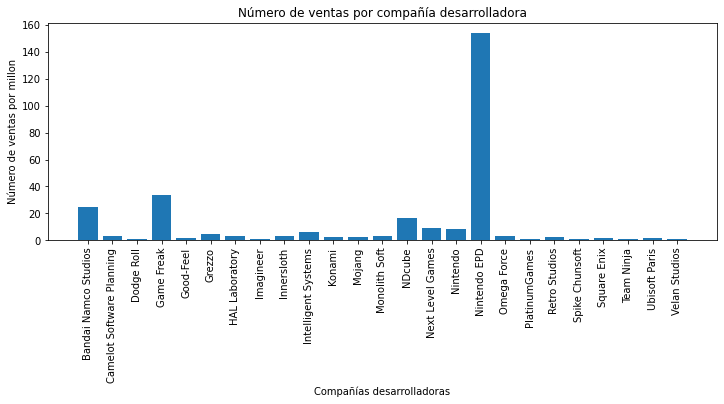

In [18]:
#Se crea una variable donde se llama a la columna 'Developer(s)' y 'Copies sold' de la base de datos,
# se agrupan los datos de 'Copies sold' con respecto a 'Developer(s)'
# y se realiza una sumatoria de los elementos de 'Copies sold' respecto a los elementos de 'Developer(s)' agrupados.
devep = df[['Developer(s)', 'Copies sold']].groupby('Developer(s)').sum()
#Se llaman los datos de la variable anteriormente creada y se separan en una variable diferente.
g = devep['Copies sold']
#Se crea una variable donde se llama a la columna 'Developer(s)' de la base de datos.
#Se realiza un conteo de los elementos que conforman esta columna.
Des_name = df['Developer(s)'].value_counts()
#Se crean variables donde se usan las funciones de pandas .sort_index()
# y .index para una mejor organizacion de la grafica y poder mostrar los nombres de los elementos de 'Developer(s)' de forma correcta.
Des_name = Des_name.sort_index()
inde = Des_name.index
#Se utilizan los parametros de mathplot para hacer la grafica de barras.
width = 0.35 
fig, ax = plt.subplots(figsize=(12,4))
#Se ponen los parametro de la grafica en sus ejes x y y.
ax.bar(inde,g)
plt.xticks(inde,rotation='vertical')
#Se ponen los label.
ax.set_xlabel('Compañías desarrolladoras')
ax.set_ylabel('Número de ventas por millon')
ax.set_title('Número de ventas por compañía desarrolladora')
plt.show()

Media ventas totales por compañías desarrolladoras:


---



In [19]:
#Se crea una variable donde se llama a la columna 'Developer(s)' de la base de datos
# y se realiza un conteo de los elementos que conforman esta columna.
Desa_num = df['Developer(s)'].value_counts()
#Se crean variables donde se usan las funciones de pandas como .sort_index() y .index,
# y en la variable donde se aplica indexa esta directamente es convertida con list en una lista.
Desa_num = Desa_num.sort_index()
inc = list(Desa_num.index)
#Se crea una funcion con un ciclo for para contar el numero de elementos que se encuetran en la lista.
def Elementos_lista(lista):
    m = 0
    for v in lista:
        m += 1
    return m
sumatoria_desarrolladores_L = int(Elementos_lista(inc))

In [21]:
suma_1 = int(df['Copies sold'].sum())
#Se crea una funcion para calcular la media 
def media(sumatoria, N_m):
 med = sumatoria/N_m
 return(med)
media_dev = media(suma_1, sumatoria_desarrolladores_L )
print(media_dev)

11.68


Porcentaje ventas por compania desarrolladora que estan por encima y debajo de la media:

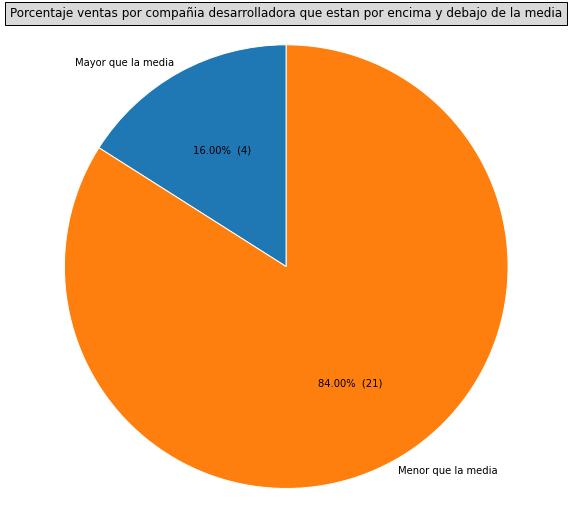

In [22]:
#Se crea una variable donde se crea una tabla agrupada por los desarrolladores y la sumatoria de ventas por millon para cada uno.
#Se usa sort values para que busque los valores y los agrupe en la tabla y se usa reset index para que restablezca el indice
# del Dataframe al indice por defecto.
W = df[['Developer(s)', 'Copies sold']].groupby('Developer(s)').sum().sort_values(by='Copies sold', ascending=False).reset_index()
#Se crea una variable que nombra 'Copies sold' respecto a W.
#Se crea una lista vacia y un for el cual utilizando if y append creara una columna extra a la base de datos,
# esta se definira respecto a los valores mayores y menores que la media de las empresas desarrolladoras.
SKw = W["Copies sold"]
Tip0=[]
for i in range(len(SKw)):
    if SKw[i] > media_dev:
        Tip0.append("Mayor que la media")
    else:
        Tip0.append("Menor que la media")
W["Tip0"]=Tip0
#Se utiliza esta nueva columna para realizar un index y procedimientos realizados anteriormente pero con variables diferentes
# para graficar los nuevos valores encontrados en una grafica circular.
TIP0_G = W['Tip0'].value_counts()
TIP0_G = TIP0_G.sort_index()
insk = TIP0_G.index

fig1, ax1 = plt.subplots(figsize=(10, 9))
def m(TIP0_G):
    def funcion_v(c):
        total = sum(TIP0_G)
        var = int(round(c*total/100.0))
        return '{p:.2f}%  ({v:d})'.format(p=c,v=var)
    return funcion_v
ax1.pie(TIP0_G, labels=insk,labeldistance=1.05, wedgeprops = { 'linewidth' : 1, 'edgecolor' : 'white' }, startangle=90, autopct= m(TIP0_G))
ax1.axis('equal') 
plt.title("Porcentaje ventas por compañia desarrolladora que estan por encima y debajo de la media", bbox={'facecolor':'0.85', 'pad':5})
plt.show()

**"Suma de empresas desarrolladoras en rangos de ventas por millón."**

Grafica:

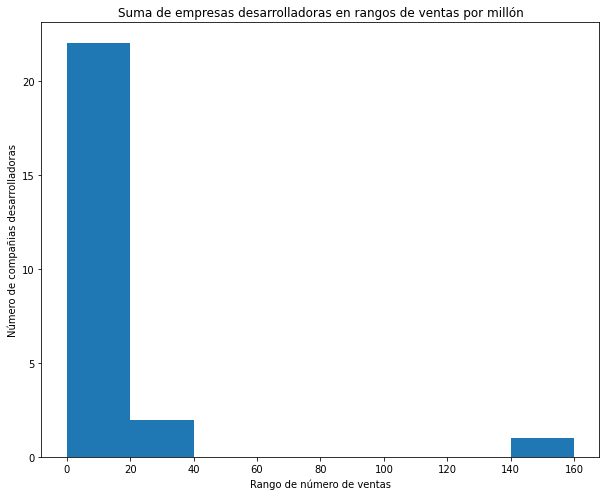

In [23]:
fig, ax = plt.subplots(figsize=(10,8))
#Se realiza la sumatoria de las ventas respecto a los desarrolladores y se nombra una variable para poder ser usada como parametro del histograma.
df_D = df[['Developer(s)', 'Copies sold']].groupby('Developer(s)').sum()
a = df_D['Copies sold']
#Parametros del histograma
#Variable, bins de la grafica
plt.hist(a, bins = [0,20,40,60,80,100,120,140,160])
plt.title("Suma de empresas desarrolladoras en rangos de ventas por millón")
ax.set_xlabel('Rango de número de ventas')
ax.set_ylabel('Número de compañias desarrolladoras')
plt.show()

**"El número de juegos publicados por cada empresa entre los más comprados."**

Tabla:

In [24]:
#Diccionario a objeto pandas del conteo del numero de videojuegos por empresa publicadora.
dhg = dict(df['Publisher(s)'].value_counts())
Serie=pd.Series(dhg)
Serie

Nintendo                      31
The Pokémon Company            2
JP: Koei Tecmo                 1
Innersloth                     1
JP: Konami                     1
JP: Xbox Game Studios          1
NA/PAL: Ubisoft                1
JP: Square Enix                1
JP: The Pokémon Company        1
Devolver Digital               1
JP: Imagineer                  1
Bandai Namco Entertainment     1
dtype: int64

Grafica:

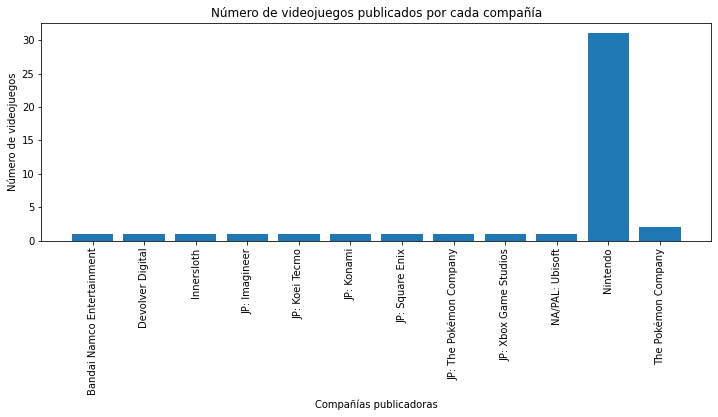

In [25]:
#Conteo videjuegos por empresa publicadora convertido indice.
Publi_num = df['Publisher(s)'].value_counts()
Publi_num = Publi_num.sort_index()
ind = Publi_num.index
#Parametros grafico de barras.
width = 0.35 
fig, ax = plt.subplots(figsize=(12,4))
#ind como el parametro x y Publi_num como y
ax.bar(ind,Publi_num)
plt.xticks(ind,rotation='vertical')
ax.set_xlabel('Compañías publicadoras')
ax.set_ylabel('Número de videojuegos')
ax.set_title('Número de videojuegos publicados por cada compañía')
plt.show()


***“Porcentaje de video juegos desarrollados por empresas first party  y second party en comparación al porcentaje de video juegos desarrollados por empresas third party, entre los videojuegos más vendidos de la consola”***

Grafica:

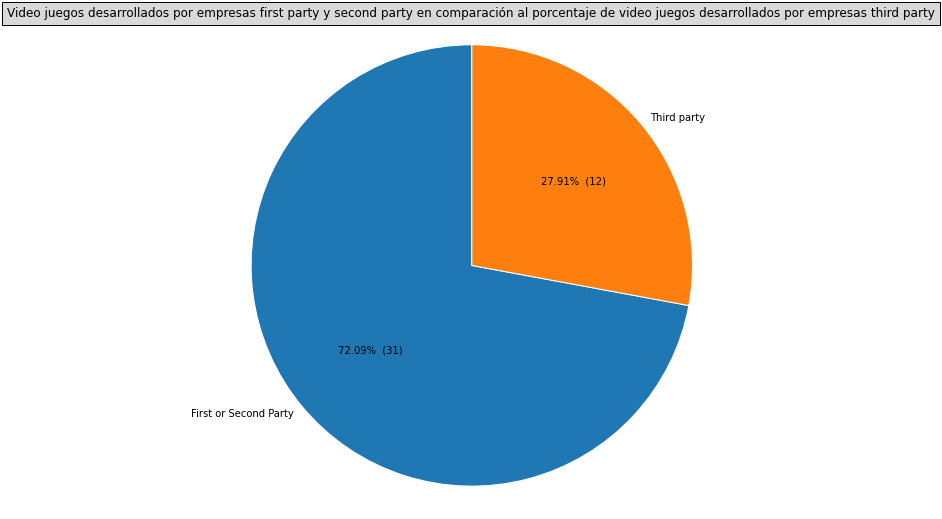

In [26]:
#Variable llama y coje datos de columna 'Publisher(s)'
I=df["Publisher(s)"]
#lista
Tipo=[]
#Ciclo, Crea una columna extra donde todos los juegos publicados por Nintendo son "First or Second Party" y el resto son "Third party"
for i in range(len(I)):
    if I[i] == "Nintendo":
        Tipo.append("First or Second Party")
    else:
        Tipo.append("Third party")
df["Tipo"]=Tipo
#Variable conteo colunma nueva
TIPO_GF = df['Tipo'].value_counts()
TIPO_GF = TIPO_GF.sort_index()
#indice
inds = TIPO_GF.index
#Parametros grafica circular
fig1, ax1 = plt.subplots(figsize=(10, 9))
#Funcion 
def m(TIPO_GF):
    def funcion_val(c):
        total = sum(TIPO_GF)
        var = int(round(c*total/100.0))
        return '{p:.2f}%  ({v:d})'.format(p=c,v=var)
    return funcion_val
#Parametros
ax1.pie(TIPO_GF, labels=inds,labeldistance=1.05, wedgeprops = { 'linewidth' : 1, 'edgecolor' : 'white' }, startangle=90, autopct= m(TIPO_GF))
ax1.axis('equal') 
plt.title("Video juegos desarrollados por empresas first party y second party en comparación al porcentaje de video juegos desarrollados por empresas third party", bbox={'facecolor':'0.85', 'pad':5})
plt.show()

**"Grafica de dispersion numero de ventas por videojuego respecto a cada empresa publicadora"**

Grafica:

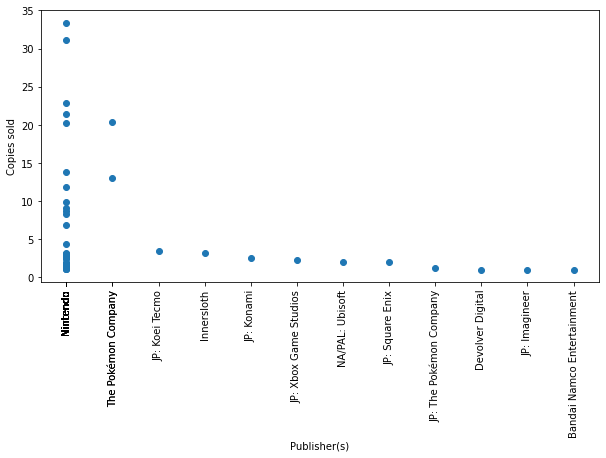

In [27]:
#Parametros grafica de dispersion
fig, ax = plt.subplots(figsize=(10,5))
#Nombra y coje los datos de las columnas 'Publisher(s)'(x) y 'Copies sold'(y)
ax.scatter(df['Publisher(s)'], df['Copies sold'])
plt.xticks(df['Publisher(s)'],rotation='vertical')
ax.set_xlabel('Publisher(s)')
ax.set_ylabel('Copies sold')
plt.show()

**"Top 10 juegos mas vendidos"**

Tabla:

In [28]:
#Nombra dos columnas y solo muestra las diez primeras filas datos
Num_P = df[['Title', 'Copies sold']].head(10)
Num_P 

,Title,Copies sold
0,Mario Kart 8 Deluxe,33.41
1,Animal Crossing: New Horizons,31.18
2,Super Smash Bros. Ultimate,22.85
3,The Legend of Zelda: Breath of the Wild,21.45
4,Pokémon Sword and Shield,20.35
5,Super Mario Odyssey,20.23
6,Super Mario Party,13.82
7,"Pokémon: Let's Go, Pikachu! and Let's Go, Eevee!",13.00
8,Splatoon 2,11.90
9,New Super Mario Bros. U Deluxe,9.82


**"Porcentaje de los juegos que estan por encima y debajo de la media de ventas por millon"**

Media de ventas por millon entre todos los videojuegos.

In [29]:
#Crea una lista con los elementos de la columna Title
S = list(df['Title'])
#Convierte a entero el valor resultante de la funcion usada
N_s = int(Elementos_lista(S))
#Utiliza funcion creada previamente
media_Total = media(suma_1,N_s)
print(media_Total)

6.790697674418604


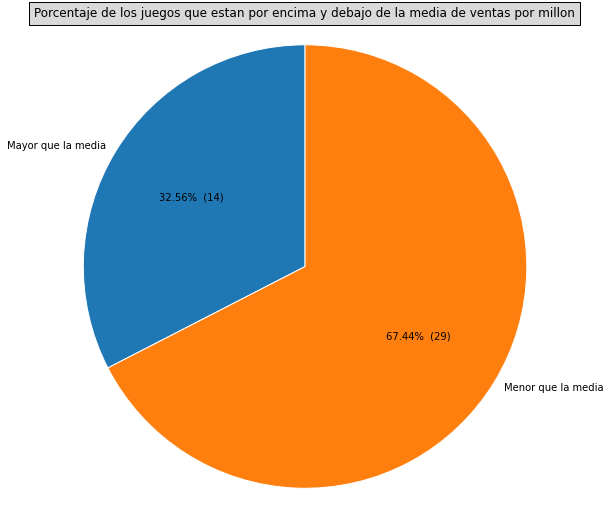

In [30]:
#Toma elementos de la columna nombrada
SK = df["Copies sold"]
#Lista
Tip=[]
#Ciclo en el cual se crea una columna nueva la cual depende de los valores de "Copies sold" 
for i in range(len(SK)):
    if SK[i] > media_Total:
        Tip.append("Mayor que la media")
    else:
        Tip.append("Menor que la media")
df["Tip"]=Tip
#Conteo columna nueva y crea indice
TIP_G = df['Tip'].value_counts()
TIP_G = TIP_G.sort_index()
inss = TIP_G.index
#Parametros grafica circular
fig1, ax1 = plt.subplots(figsize=(10, 9))
#Funcion numero al lado de porcentaje
def m(TIP_G):
    def funcion_v(c):
        total = sum(TIP_G)
        var = int(round(c*total/100.0))
        return '{p:.2f}%  ({v:d})'.format(p=c,v=var)
    return funcion_v
#Parametros 
ax1.pie(TIP_G, labels=inss,labeldistance=1.05, wedgeprops = { 'linewidth' : 1, 'edgecolor' : 'white' }, startangle=90, autopct= m(TIP_G))
ax1.axis('equal') 
plt.title("Porcentaje de los juegos que estan por encima y debajo de la media de ventas por millon", bbox={'facecolor':'0.85', 'pad':5})
plt.show()